## Import de librerías

In [1]:
# Import de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import statsmodels.api as sm
import glob
import polars as pl
import timeit


## Import de dataset

In [ ]:
# path a los archivos parquet
##files = glob.glob("../dataset/*.parquet")
files = glob.glob("../dataset/01-raw/yellow_tripdata_2024-01.parquet")

# leer .parquet files y concatenar en un solo df 
df = pd.concat([pd.read_parquet(f) for f in files], ignore_index=True)

print(len(files), "files merged")
print(df.shape)

# Formato de visualización de floats en pandas
pd.set_option('display.float_format', '{:.2f}'.format)


1 files merged
(2964624, 19)


In [3]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,1.00,N,186,79,2,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,1.00,N,140,236,1,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,1.00,N,236,79,1,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.00,1.40,1.00,N,79,211,1,10.00,3.50,0.50,2.00,0.00,1.00,17.00,2.50,0.00
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.00,0.80,1.00,N,211,148,1,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00


In [4]:

df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2964624.00,2964624,2964624,2824462.00,2964624.00,2824462.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2964624.00,2824462.00,2824462.00
mean,1.75,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.34,3.65,2.07,166.02,165.12,1.16,18.18,1.45,0.48,3.34,0.53,0.98,26.80,2.26,0.14
min,1.00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.00,0.00,1.00,1.00,1.00,0.00,-899.00,-7.50,-0.50,-80.00,-80.00,-1.00,-900.00,-2.50,-1.75
25%,2.00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.00,1.00,1.00,132.00,114.00,1.00,8.60,0.00,0.50,1.00,0.00,1.00,15.38,2.50,0.00
50%,2.00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.00,1.68,1.00,162.00,162.00,1.00,12.80,1.00,0.50,2.70,0.00,1.00,20.10,2.50,0.00
75%,2.00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.00,3.11,1.00,234.00,234.00,1.00,20.50,2.50,0.50,4.12,0.00,1.00,28.56,2.50,0.00
max,6.00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.00,312722.30,99.00,265.00,265.00,4.00,5000.00,14.25,4.00,428.00,115.92,1.00,5000.00,2.50,1.75
std,0.43,NaN,NaN,0.85,225.46,9.82,63.62,69.32,0.58,18.95,1.80,0.12,3.90,2.13,0.22,23.39,0.82,0.49


In [5]:
# print tipo de columnas
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

## Análisis de valores nulos 

In [6]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df.isnull().mean() * 100
nulos_absolute = df.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
VendorID                            0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                140162              4.73
trip_distance                       0              0.00
RatecodeID                     140162              4.73
store_and_fwd_flag             140162              4.73
PULocationID                        0              0.00
DOLocationID                        0              0.00
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0           

<Axes: >

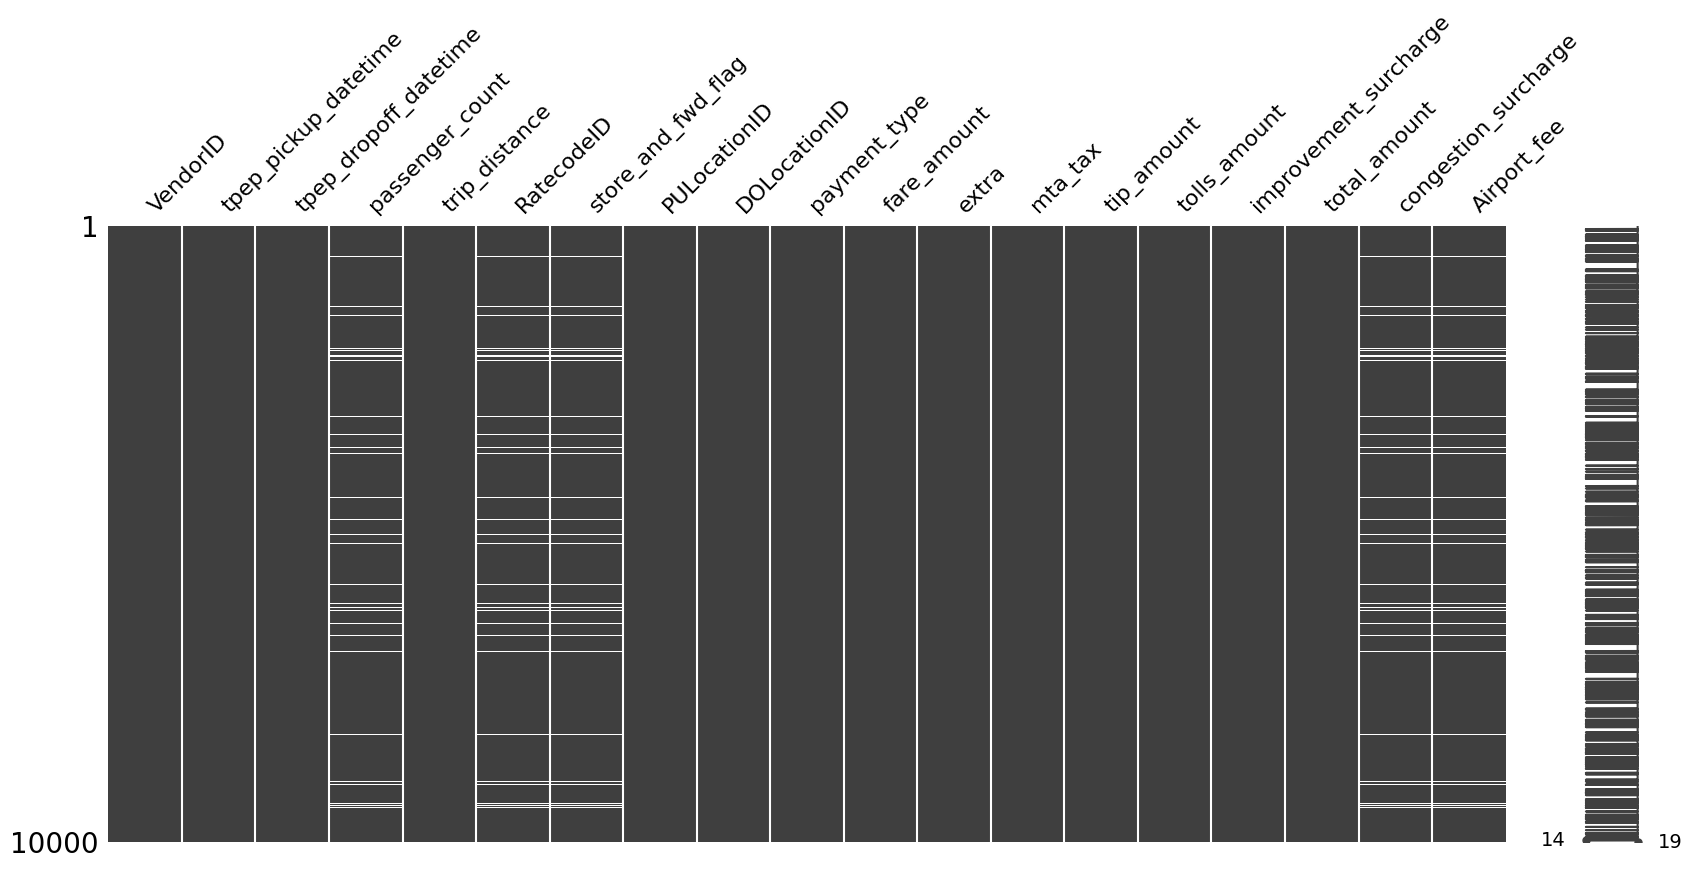

In [7]:
# Matriz de valores faltantes
msno.matrix(df.sample(10000, random_state=42), figsize=(20, 8))

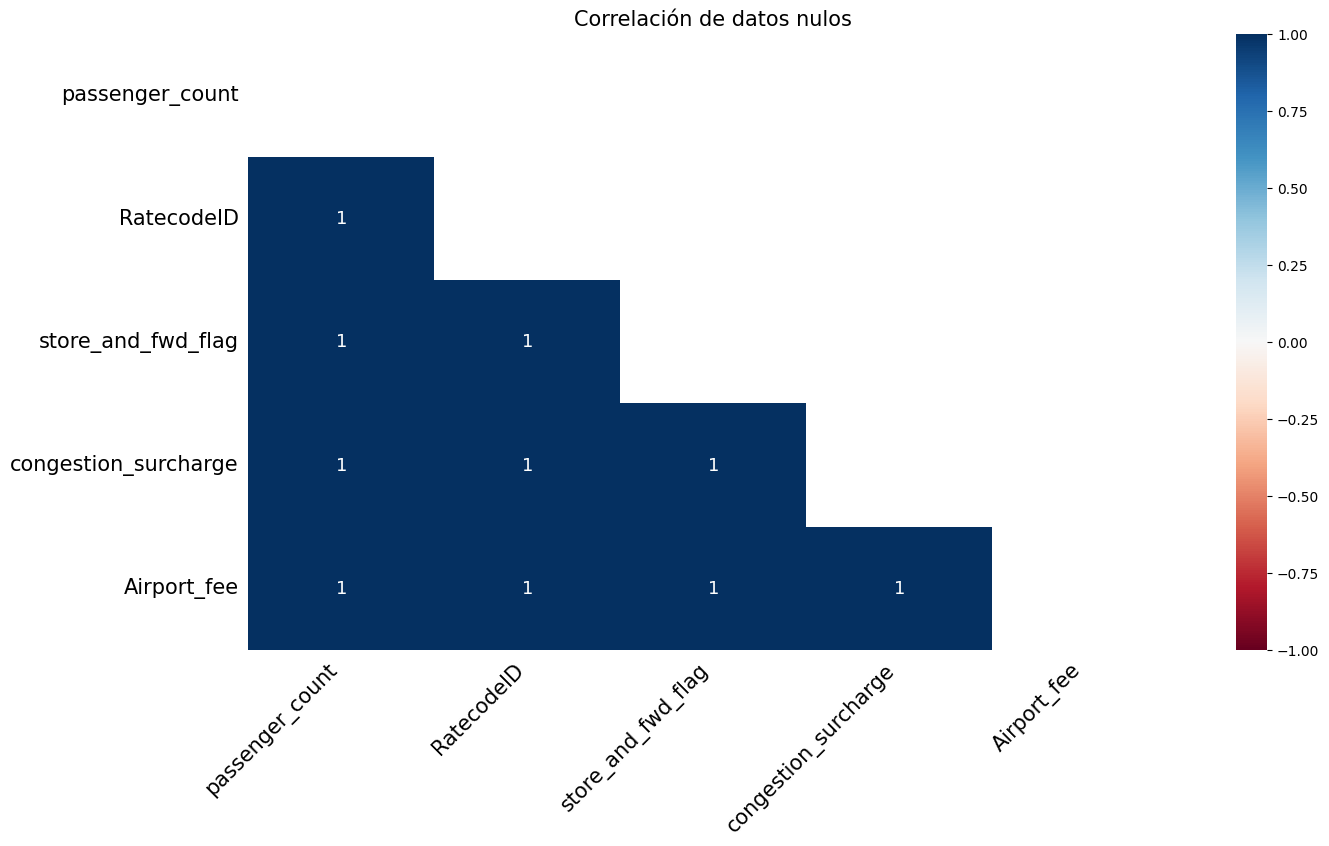

In [8]:
msno.heatmap(df, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

In [9]:
# Si bien supuestamente tenemos solo esos nulos que se ven ahi, tenemos que tener en cuenta que segun la descripcion del dataset también se debe tener en cuenta que: 
# Para RatecodeID: 99 es Unknown/Null
# Para payment_type: 5 es Unknown/Null
# Convertimos esos valores a NaN
df['RatecodeID'] = df['RatecodeID'].replace(99, np.nan)
df['payment_type'] = df['payment_type'].replace(5, np.nan)

In [10]:
# obtener valores unicos de payment type
print(df['payment_type'].unique())
# nans 
print(df['payment_type'].isnull().sum())

[2 1 4 3 0]
0


In [11]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df.isnull().mean() * 100
nulos_absolute = df.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
VendorID                            0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                140162              4.73
trip_distance                       0              0.00
RatecodeID                     168825              5.69
store_and_fwd_flag             140162              4.73
PULocationID                        0              0.00
DOLocationID                        0              0.00
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0           

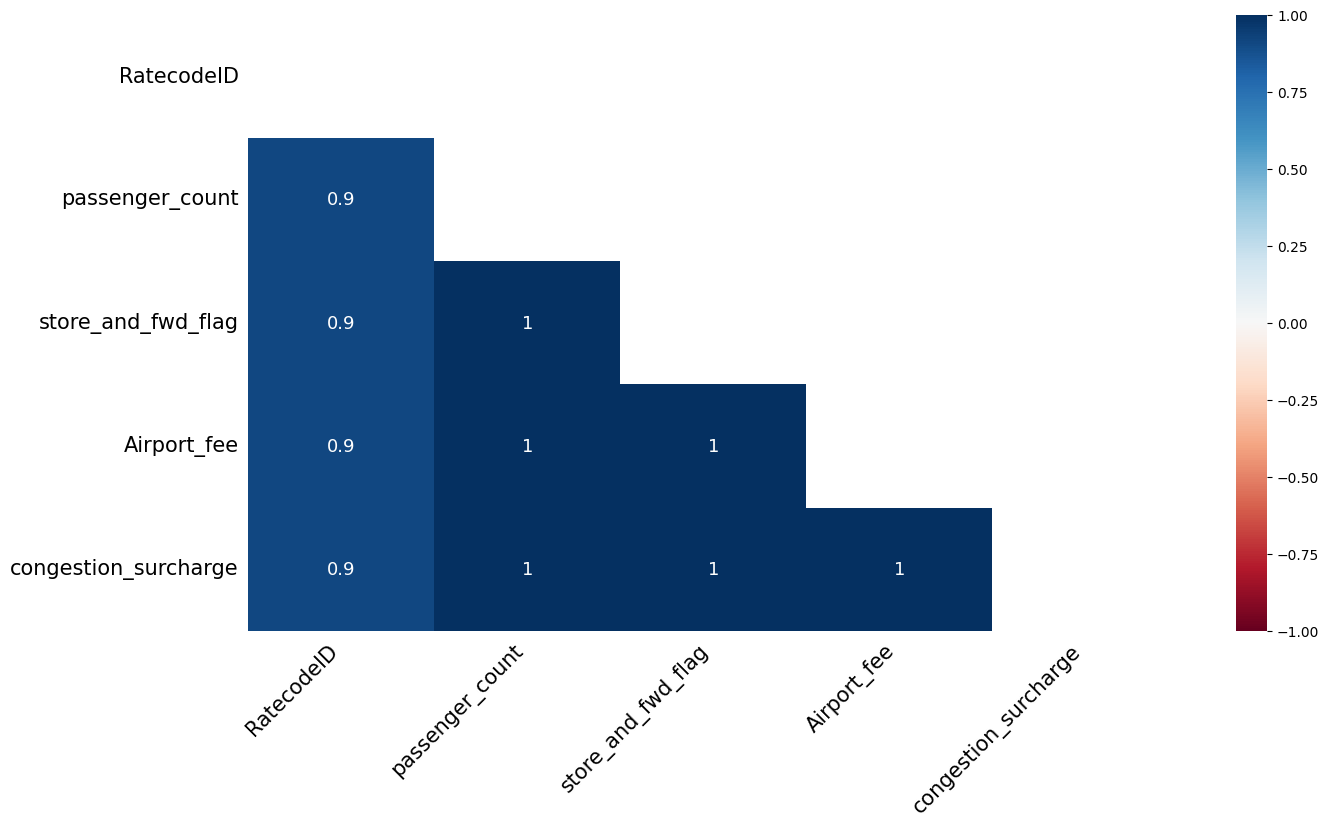

In [12]:
# Calcular cantidad de NaN por columna
missing_counts = df.isna().sum()
# Ordenar columnas: primero las con más NaN, al final las con menos
sorted_cols = missing_counts.sort_values(ascending=False).index.tolist()
# Reordenar DataFrame
df_sorted = df[sorted_cols]

# Graficar heatmap con el nuevo orden
fig, ax = plt.subplots(figsize=(15, 8))
msno.heatmap(df_sorted, fontsize=15, ax=ax)

# Opcional: cambiar color del texto dentro de las celdas
for text in ax.texts:
    text.set_color("white")

plt.show()

## Decoding de variables categóricas y ajuste de tipos de datos

Se realiza el decoding de estas variables para luego poder decidir que se hace con cada una de ellas. 

In [13]:
'''
Verificar si columna "store_and_fwd_flag" tiene valores distintos a 'Y' y 'N' si no, 
se cambia a tipo booleano
'''
print(df['store_and_fwd_flag'].value_counts())

# Como es solo 'Y' y 'N', se cambia a booleano
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].map({'Y': True, 'N': False})
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].astype('boolean')
# Verificamos el cambio
df.info()

store_and_fwd_flag
N    2813126
Y      11336
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int32         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     boolean       
 7   PULocationID           int32         
 8   DOLocationID           int32         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       

In [14]:
# decoding de variables codificadas por diccionarios 
vendor_dict = {
    1: "Creative Mobile Technologies, LLC",
    2: "Curb Mobility, LLC",
    6: "Myle Technologies Inc",
    7: "Helix"
}

ratecode_dict = {
    1: "Standard rate",
    2: "JFK",
    3: "Newark",
    4: "Nassau or Westchester",
    5: "Negotiated fare",
    6: "Group ride",
    99: "Null/unknown"
}

payment_dict = {
    0: "Flex Fare trip",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided trip"
}

# con diccionarios hacemos decoding 
df["VendorID"] = df["VendorID"].map(vendor_dict)
df["RatecodeID"] = df["RatecodeID"].map(ratecode_dict)
df["payment_type"] = df["payment_type"].map(payment_dict)

In [15]:
df.head(5)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,Standard rate,False,186,79,Cash,17.70,1.00,0.50,0.00,0.00,1.00,22.70,2.50,0.00
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,Standard rate,False,140,236,Credit card,10.00,3.50,0.50,3.75,0.00,1.00,18.75,2.50,0.00
2,"Creative Mobile Technologies, LLC",2024-01-01 00:17:06,2024-01-01 00:35:01,1.00,4.70,Standard rate,False,236,79,Credit card,23.30,3.50,0.50,3.00,0.00,1.00,31.30,2.50,0.00
3,"Creative Mobile Technologies, LLC",2024-01-01 00:36:38,2024-01-01 00:44:56,1.00,1.40,Standard rate,False,79,211,Credit card,10.00,3.50,0.50,2.00,0.00,1.00,17.00,2.50,0.00
4,"Creative Mobile Technologies, LLC",2024-01-01 00:46:51,2024-01-01 00:52:57,1.00,0.80,Standard rate,False,211,148,Credit card,7.90,3.50,0.50,3.20,0.00,1.00,16.10,2.50,0.00


In [16]:
# Taxi zone requiere técnicas de data enrichment. Importamos dataset de taxi_zone_lookup
taxi_zones = pd.read_csv(r"..\dataset\taxi_zone_lookup.csv")
taxi_zones.head(5)

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [17]:
# Se debe mapear entonces cada ID con la "Zone"
df = df.merge(
    taxi_zones,
    left_on='PULocationID',
    right_on='LocationID',
    how='left'
)
df = df.rename(columns={
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})


In [18]:
df.drop(columns=["LocationID","PULocationID"], inplace=True)
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,DOLocationID,payment_type,fare_amount,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,Standard rate,False,79,Cash,17.70,...,0.50,0.00,0.00,1.00,22.70,2.50,0.00,Manhattan,Penn Station/Madison Sq West,Yellow Zone
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,Standard rate,False,236,Credit card,10.00,...,0.50,3.75,0.00,1.00,18.75,2.50,0.00,Manhattan,Lenox Hill East,Yellow Zone


In [19]:

# Se debe mapear entonces cada ID con la "Zone"
df = df.merge(
    taxi_zones,
    left_on='DOLocationID',
    right_on='LocationID',
    how='left'
)
df = df.rename(columns={
    "Borough": "dropoff_borough",
    "Zone": "dropoff_zone",
    "service_zone": "dropoff_service_zone"
})


In [20]:
df.drop(columns=["LocationID","DOLocationID"],inplace=True)
df.head(2)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
0,"Curb Mobility, LLC",2024-01-01 00:57:55,2024-01-01 01:17:43,1.00,1.72,Standard rate,False,Cash,17.70,1.00,...,1.00,22.70,2.50,0.00,Manhattan,Penn Station/Madison Sq West,Yellow Zone,Manhattan,East Village,Yellow Zone
1,"Creative Mobile Technologies, LLC",2024-01-01 00:03:00,2024-01-01 00:09:36,1.00,1.80,Standard rate,False,Credit card,10.00,3.50,...,1.00,18.75,2.50,0.00,Manhattan,Lenox Hill East,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone


In [21]:
df = df.rename(columns={
    "VendorID": "vendor",
    "RatecodeID": "ratecode",
})

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2964624 entries, 0 to 2964623
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor                 object        
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   ratecode               object        
 6   store_and_fwd_flag     boolean       
 7   payment_type           object        
 8   fare_amount            float64       
 9   extra                  float64       
 10  mta_tax                float64       
 11  tip_amount             float64       
 12  tolls_amount           float64       
 13  improvement_surcharge  float64       
 14  total_amount           float64       
 15  congestion_surcharge   float64       
 16  Airport_fee            float64       
 17  pickup_borough         object        
 18  pickup_zone           

In [23]:
# convertimos a int floats que no correspondan
df["passenger_count"] = df["passenger_count"].astype('Int64')


### Export de dataset a .parquet

In [29]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
# agregamos columna mes y separamos
df['month'] = df['tpep_pickup_datetime'].dt.month
for month, group in df.groupby('month'):
    group.drop(columns=['month'], inplace=True)
    group.to_parquet(f"../dataset/02-preprocessed/yellow_tripdata_2024-{month:02d}.parquet", index=False)

## Tratamiento de valores nulos

### Análisis general

In [25]:
# Crea un sub-DataFrame con las filas que tienen CUALQUIER valor nulo
nulos_subdf = df[df.isnull().any(axis=1)]

# Muestra el número de filas encontradas
print(f"Total de filas con al menos un valor nulo: {len(nulos_subdf)}")

# Muestra las primeras 5 filas para su inspección
nulos_subdf.head(5)

Total de filas con al menos un valor nulo: 199386


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,month
23,"Creative Mobile Technologies, LLC",2024-01-01 00:14:29,2024-01-01 00:14:29,1,0.00,Standard rate,False,Cash,3.00,3.50,...,8.00,2.50,0.00,Manhattan,Upper East Side North,Yellow Zone,Unknown,NaN,NaN,1
24,"Creative Mobile Technologies, LLC",2024-01-01 00:42:05,2024-01-01 01:16:49,1,23.90,Negotiated fare,False,Credit card,120.00,0.00,...,127.94,0.00,0.00,Manhattan,Yorkville West,Yellow Zone,NaN,Outside of NYC,NaN,1
122,"Creative Mobile Technologies, LLC",2024-01-01 00:34:00,2024-01-01 00:56:49,2,2.90,Standard rate,False,Credit card,21.20,3.50,...,30.13,2.50,0.00,Manhattan,Central Park,Yellow Zone,Unknown,NaN,NaN,1
177,"Curb Mobility, LLC",2024-01-01 00:16:21,2024-01-01 00:46:36,1,23.00,Nassau or Westchester,False,Cash,125.50,6.00,...,134.75,0.00,1.75,Queens,East Elmhurst,Boro Zone,NaN,Outside of NYC,NaN,1
198,"Creative Mobile Technologies, LLC",2024-01-01 00:15:16,2024-01-01 00:26:58,2,0.00,Standard rate,False,Credit card,10.70,3.50,...,18.80,2.50,0.00,Manhattan,East Village,Yellow Zone,Unknown,NaN,NaN,1


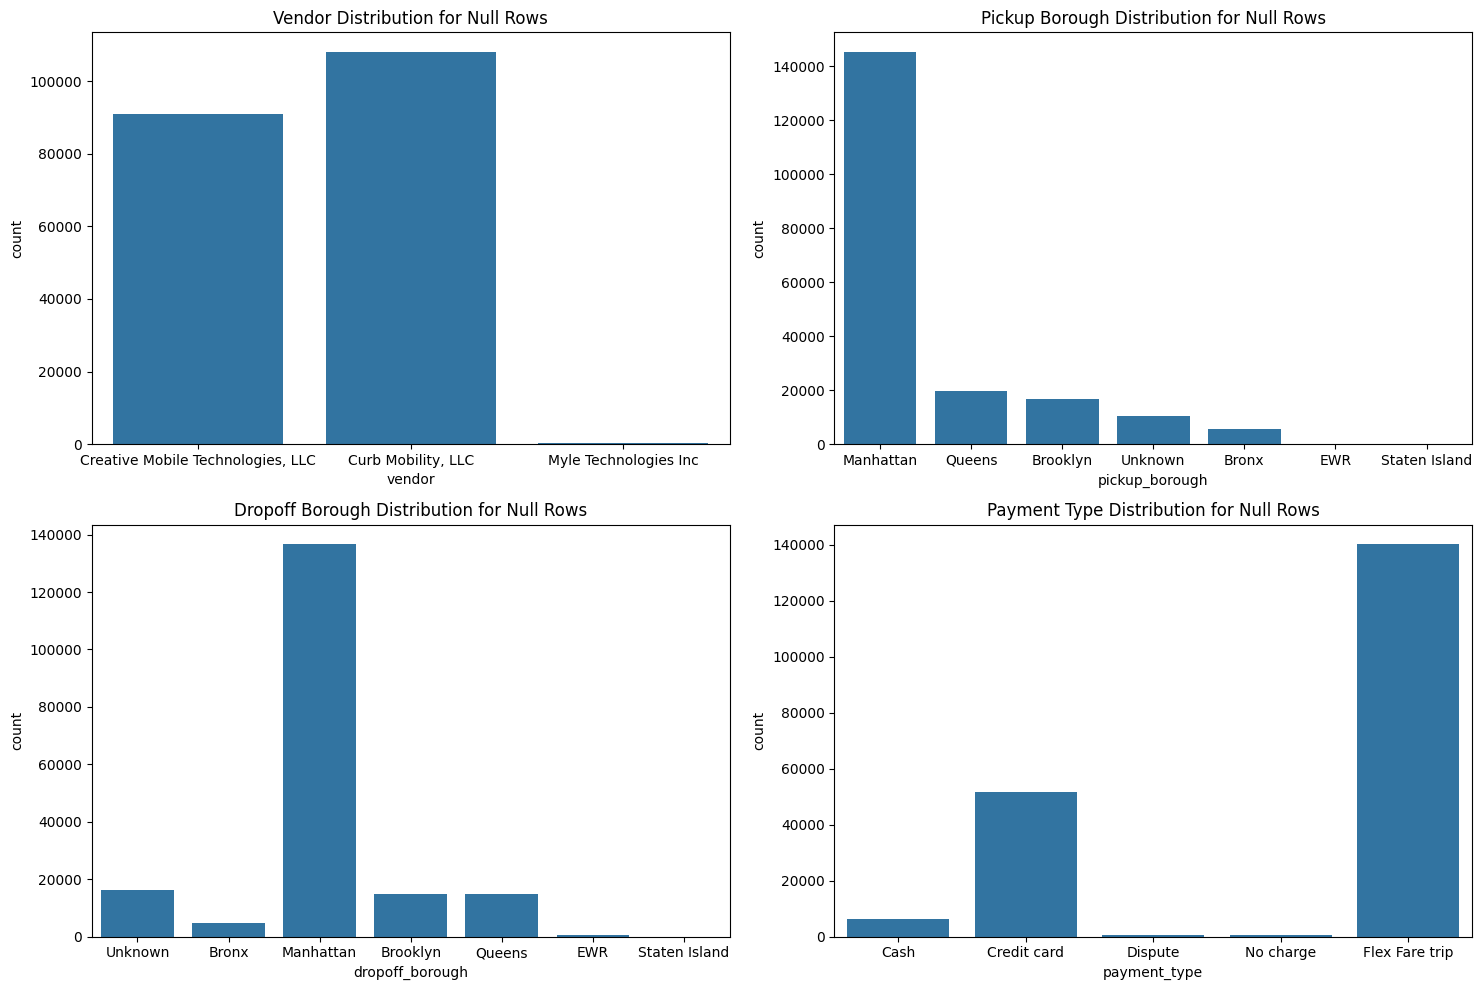

In [26]:
# subplots con: vendor, pickup_borough, dropoff_borough, payment_type
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.countplot(data=nulos_subdf, x='vendor', ax=axes[0,0])
axes[0,0].set_title('Vendor Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='pickup_borough', ax=axes[0,1])
axes[0,1].set_title('Pickup Borough Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='dropoff_borough', ax=axes[1,0])
axes[1,0].set_title('Dropoff Borough Distribution for Null Rows')
sns.countplot(data=nulos_subdf, x='payment_type', ax=axes[1,1])
axes[1,1].set_title('Payment Type Distribution for Null Rows')
plt.tight_layout()

### Dropoff y pickup borough

In [27]:
# dropoff borough nulos solo corresponden cuando el viaje termina en nueva york. Por lo tanto reemplazamos por "Outside of NYC" si dropoff_zone es "Outside of NYC"
df.loc[(df['dropoff_borough'].isnull()) & (df['dropoff_zone'] == 'Outside of NYC'), 'dropoff_borough'] = 'Outside of NYC'
# idem con pickup
df.loc[(df['pickup_borough'].isnull()) & (df['pickup_zone'] == 'Outside of NYC'), 'pickup_borough'] = 'Outside of NYC'


In [28]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df.isnull().mean() * 100
nulos_absolute = df.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                140162              4.73
trip_distance                       0              0.00
ratecode                       168825              5.69
store_and_fwd_flag             140162              4.73
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           140162              4.73
Airport_fee                    140162           

### Filtro por NYC

In [43]:
# si filtramos las filas que no sean outside of NYC en pickup y dropoff
df_nyc = df[(df['pickup_zone'] != 'Outside of NYC') & (df['dropoff_zone'] != 'Outside of NYC')]

In [44]:
# cantidades de nulos para dropoff y pickup en total son bajos. podemos descartarlos a propositos del dataset. 
# drop nulls para dropoff y pickup
df_nyc = df_nyc.dropna(subset=['dropoff_borough','dropoff_zone','dropoff_service_zone','pickup_borough','pickup_zone', 'pickup_service_zone'])


In [45]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                139314              4.75
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           139314              4.75
Airport_fee                    139314           

### Airport fee

In [46]:
# analicemos las filas que contienen nulos en airport_fee con un head
df_nyc[df_nyc['Airport_fee'].isnull()].head(5)


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
2824462,"Curb Mobility, LLC",2024-01-01 00:34:19,2024-01-01 00:51:22,<NA>,2.04,NaN,<NA>,Flex Fare trip,12.72,0.00,...,1.00,16.72,NaN,NaN,Manhattan,Lincoln Square West,Yellow Zone,Manhattan,Lenox Hill West,Yellow Zone
2824463,"Creative Mobile Technologies, LLC",2024-01-01 00:14:31,2024-01-01 00:19:29,<NA>,1.60,NaN,<NA>,Flex Fare trip,9.30,1.00,...,1.00,17.16,NaN,NaN,Manhattan,Upper East Side North,Yellow Zone,Manhattan,Upper West Side North,Yellow Zone
2824464,"Creative Mobile Technologies, LLC",2024-01-01 00:35:11,2024-01-01 01:13:40,<NA>,0.00,NaN,<NA>,Flex Fare trip,21.01,0.00,...,1.00,25.01,NaN,NaN,Manhattan,Lincoln Square East,Yellow Zone,Manhattan,East Village,Yellow Zone
2824465,"Creative Mobile Technologies, LLC",2024-01-01 00:33:37,2024-01-01 00:50:34,<NA>,0.00,NaN,<NA>,Flex Fare trip,17.79,0.00,...,1.00,21.79,NaN,NaN,Manhattan,Upper East Side South,Yellow Zone,Manhattan,Alphabet City,Yellow Zone
2824466,"Creative Mobile Technologies, LLC",2024-01-01 00:49:04,2024-01-01 01:01:16,<NA>,0.00,NaN,<NA>,Flex Fare trip,34.65,0.00,...,1.00,38.65,NaN,NaN,Manhattan,Washington Heights South,Boro Zone,Manhattan,Clinton West,Yellow Zone


In [47]:
# convertir objects a categoricas
categorical_cols = ['vendor', 'ratecode', 'payment_type', 'pickup_borough', 'pickup_zone', 'pickup_service_zone', 'dropoff_borough', 'dropoff_zone', 'dropoff_service_zone']
for col in categorical_cols:
    df_nyc[col] = df_nyc[col].astype('category')
df_nyc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2933097 entries, 0 to 2964623
Data columns (total 23 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   vendor                 category      
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        Int64         
 4   trip_distance          float64       
 5   ratecode               category      
 6   store_and_fwd_flag     boolean       
 7   payment_type           category      
 8   fare_amount            float64       
 9   extra                  float64       
 10  mta_tax                float64       
 11  tip_amount             float64       
 12  tolls_amount           float64       
 13  improvement_surcharge  float64       
 14  total_amount           float64       
 15  congestion_surcharge   float64       
 16  Airport_fee            float64       
 17  pickup_borough         category      
 18  pickup_zone            cate

In [48]:
df_nyc.describe(include='category')

,vendor,ratecode,payment_type,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone
count,2933097,2765238,2933097,2933097,2933097,2933097,2933097,2933097,2933097
unique,2,6,5,6,256,4,6,258,4
top,"Curb Mobility, LLC",Standard rate,Credit card,Manhattan,Midtown Center,Yellow Zone,Manhattan,Upper East Side North,Yellow Zone
freq,2217804,2643882,2295930,2636215,142942,2581206,2654034,141928,2520724


In [49]:
# verificar si algun airport_fee nulo tiene ratecode JFK o Newark
df_nyc[(df_nyc['Airport_fee'].isnull()) & (df_nyc['ratecode'].isin(['JFK', 'Newark']))]
# ninguno

,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,store_and_fwd_flag,payment_type,fare_amount,extra,...,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone


In [50]:
# Definimos la condición: Zona de recogida es 'Airports' Y la tarifa de aeropuerto es nula
df_nyc[(df_nyc['pickup_service_zone'] == 'Airports') & (df_nyc['Airport_fee'].isnull())].shape[0]


846

In [51]:
condicion_imputacion = (
    df_nyc['Airport_fee'].isnull() & 
    (
        (df_nyc['pickup_service_zone'] == 'Airports') | 
        (df_nyc['dropoff_service_zone'] == 'Airports')
    )
)
# 1.75 a los que cumplen condicion
df_nyc.loc[condicion_imputacion, 'Airport_fee'] = 1.75
# 0 a los que no
df_nyc['Airport_fee'] = df_nyc['Airport_fee'].fillna(0)

In [52]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                139314              4.75
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge           139314              4.75
Airport_fee                         0           

### Congestion surcharge

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\1440291825.py:9: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_nyc, x='hour_bin', y='congestion_surcharge', ci=None)


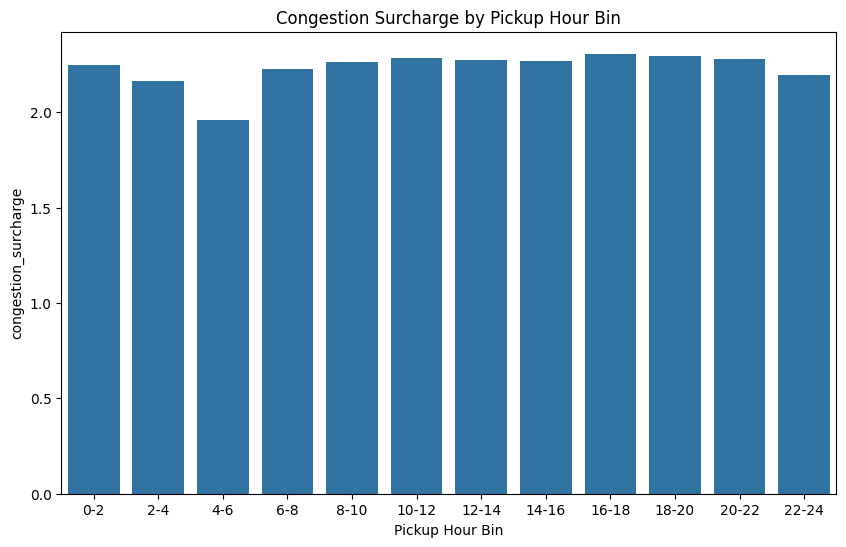

In [53]:
# analicemos el congestion_surcharge
# temporalmente creamos bins de horarios a partir de tpep_pickup_datetime para ver si hay alguna relación entre horario y congestion_surcharge
df_nyc['pickup_hour'] = df_nyc['tpep_pickup_datetime'].dt.hour
df_nyc['hour_bin'] = pd.cut(df_nyc['pickup_hour'], bins=[-1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24], 
                            labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-12', '12-14', '14-16', '16-18', '18-20', '20-22', '22-24'])

# grafico de barras de congestion_surcharge por hour_bin
plt.figure(figsize=(10,6))
sns.barplot(data=df_nyc, x='hour_bin', y='congestion_surcharge', ci=None)
plt.title('Congestion Surcharge by Pickup Hour Bin')
plt.xlabel('Pickup Hour Bin')
plt.show()

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\999623525.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_nyc[df_nyc['congestion_surcharge'] > 0].groupby('pickup_hour')['congestion_surcharge'].sum().reset_index(), x='pickup_hour', y='congestion_surcharge', ci=None)


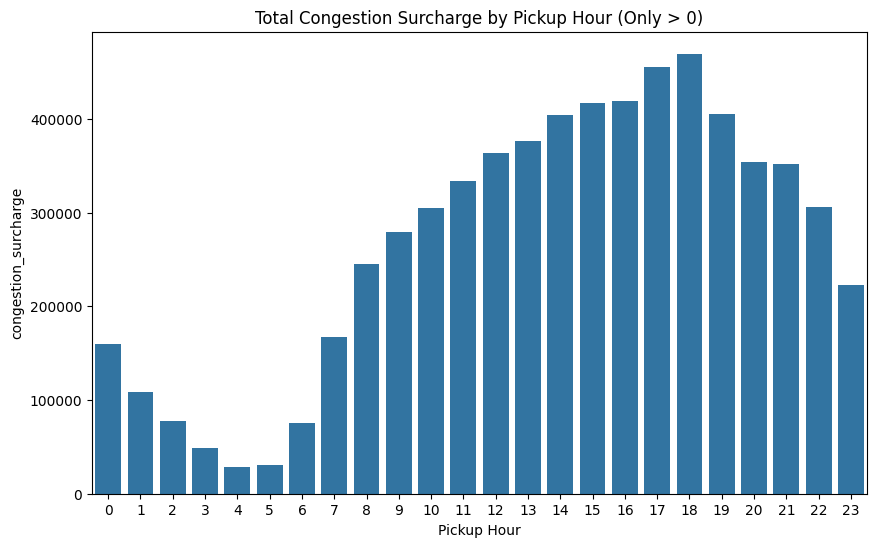

In [54]:
# plot de sum de registros de congestion_surcharge por pickup hour cuando congestion_surcharge > 0
plt.figure(figsize=(10,6))
sns.barplot(data=df_nyc[df_nyc['congestion_surcharge'] > 0].groupby('pickup_hour')['congestion_surcharge'].sum().reset_index(), x='pickup_hour', y='congestion_surcharge', ci=None)
plt.title('Total Congestion Surcharge by Pickup Hour (Only > 0)')
plt.xlabel('Pickup Hour')
plt.show()

In [55]:
# Calculamos probabilidad de que congestion_surcharge > 0 por pickup_hour
prob_congestion_by_hour = df_nyc.groupby('pickup_hour')['congestion_surcharge'].apply(lambda x: (x > 0).mean()).reset_index(name='prob_congestion_surcharge_gt_0')
# en base a esto imputamos a los valores nulos el valor 2.5 con una probabilidad igual a la calculada de que congestion_surcharge > 0 por pickup_hour
def imputar_congestion_surcharge(row):
    if pd.isnull(row['congestion_surcharge']):
        prob = prob_congestion_by_hour.loc[prob_congestion_by_hour['pickup_hour'] == row['pickup_hour'], 'prob_congestion_surcharge_gt_0'].values[0]
        if np.random.rand() < prob:
            return 2.5
        else:
            return 0.0
    else:
        return row['congestion_surcharge']
df_nyc['congestion_surcharge'] = df_nyc.apply(imputar_congestion_surcharge, axis=1)


In [56]:
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                139314              4.75
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0           

### Passenger count 

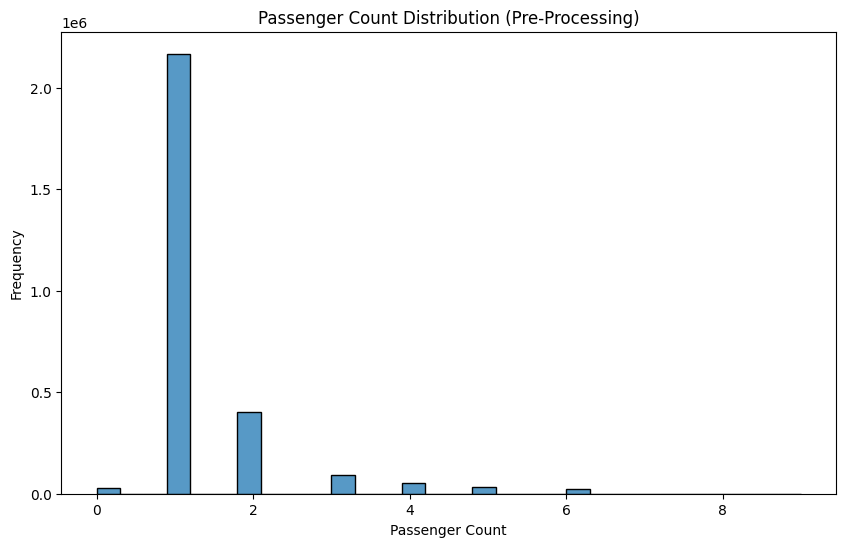

In [57]:
# histograma passenger count pre procesamiento
plt.figure(figsize=(10,6))
sns.histplot(df_nyc['passenger_count'].dropna(), bins=30, kde=False)
plt.title('Passenger Count Distribution (Pre-Processing)')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.show()

In [58]:
# passenger count lo imputamos por criterio de serie temporal. primero ffill luego bfill para asegurar completitud.
df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\620267316.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')


                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                     0              0.00
trip_distance                       0              0.00
ratecode                       167859              5.72
store_and_fwd_flag             139314              4.75
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0           

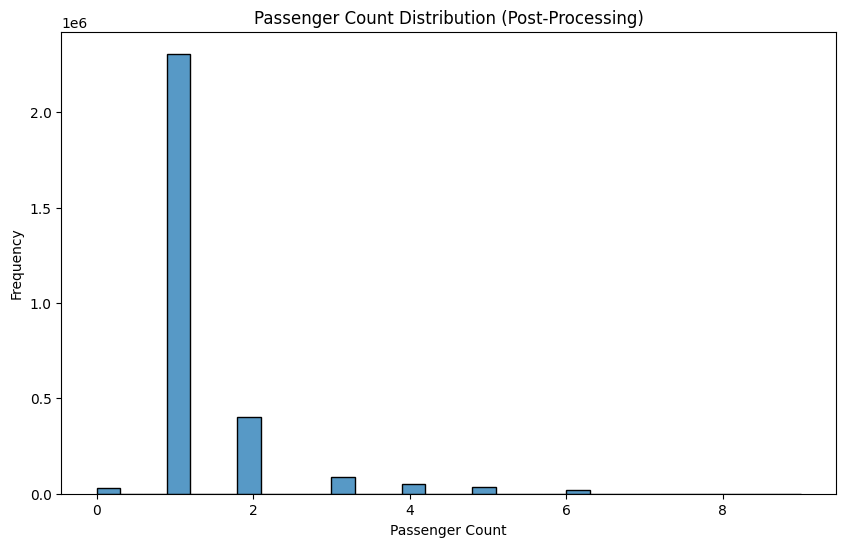

In [59]:
# histograma passenger count pos procesamiento
plt.figure(figsize=(10,6))
sns.histplot(df_nyc['passenger_count'].dropna(), bins=30, kde=False)
plt.title('Passenger Count Distribution (Post-Processing)')
plt.xlabel('Passenger Count')
plt.ylabel('Frequency')
plt.show()

### Store and fwd

In [60]:
# store and fwd no agrega valor al analisis
df_nyc = df_nyc.drop(columns=['store_and_fwd_flag'])

In [61]:
# passenger count lo imputamos por criterio de serie temporal. primero ffill luego bfill para asegurar completitud.
df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\620267316.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')


                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                     0              0.00
trip_distance                       0              0.00
ratecode                       167859              5.72
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0              0.00
pickup_borough                      0           

### Ratecode

In [62]:
# analicemos las filas que sean ratecode JFK o Newark y veamos valores de pickup y dropoff 
df_nyc[df_nyc['ratecode'].isin(['Newark'])].head(10)


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,payment_type,fare_amount,extra,mta_tax,...,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin
1859,"Curb Mobility, LLC",2024-01-01 00:37:22,2024-01-01 01:21:01,4,17.43,Newark,Credit card,93.00,1.00,0.00,...,0.00,0.00,Manhattan,Lincoln Square East,Yellow Zone,EWR,Newark Airport,EWR,0,0-2
4796,"Curb Mobility, LLC",2024-01-01 00:07:49,2024-01-01 00:08:18,1,0.47,Newark,Cash,24.40,1.00,0.00,...,0.00,0.00,Queens,South Ozone Park,Boro Zone,Queens,JFK Airport,Airports,0,0-2
5019,"Curb Mobility, LLC",2024-01-01 00:45:47,2024-01-01 01:06:28,3,5.21,Newark,Credit card,47.50,1.00,0.00,...,0.00,0.00,Manhattan,Clinton West,Yellow Zone,Manhattan,East Harlem North,Boro Zone,0,0-2
5228,"Curb Mobility, LLC",2024-01-01 00:05:40,2024-01-01 01:00:23,1,16.13,Newark,Cash,83.90,1.00,0.00,...,0.00,1.75,Queens,JFK Airport,Airports,Brooklyn,Prospect-Lefferts Gardens,Boro Zone,0,0-2
5271,"Curb Mobility, LLC",2024-01-01 00:15:16,2024-01-01 00:15:41,2,0.06,Newark,Cash,23.00,1.00,0.00,...,0.00,0.00,Manhattan,Midtown North,Yellow Zone,Manhattan,Midtown North,Yellow Zone,0,0-2
5676,"Creative Mobile Technologies, LLC",2024-01-01 01:28:22,2024-01-01 01:35:01,2,0.80,Newark,Dispute,27.90,1.00,0.00,...,0.00,0.00,Manhattan,Flatiron,Yellow Zone,Manhattan,West Village,Yellow Zone,1,0-2
6292,"Curb Mobility, LLC",2024-01-01 01:55:48,2024-01-01 02:37:02,2,17.75,Newark,Credit card,92.30,1.00,0.00,...,0.00,0.00,Manhattan,Midtown North,Yellow Zone,EWR,Newark Airport,EWR,1,0-2
8315,"Curb Mobility, LLC",2024-01-01 01:46:42,2024-01-01 01:47:00,1,0.00,Newark,Credit card,23.00,1.00,0.00,...,0.00,0.00,Manhattan,UN/Turtle Bay South,Yellow Zone,Manhattan,UN/Turtle Bay South,Yellow Zone,1,0-2
8746,"Curb Mobility, LLC",2024-01-01 01:00:45,2024-01-01 01:00:59,3,0.00,Newark,Dispute,-23.00,-1.00,0.00,...,0.00,-1.75,Queens,JFK Airport,Airports,Queens,JFK Airport,Airports,1,0-2
8747,"Curb Mobility, LLC",2024-01-01 01:00:45,2024-01-01 01:00:59,3,0.00,Newark,Dispute,23.00,1.00,0.00,...,0.00,1.75,Queens,JFK Airport,Airports,Queens,JFK Airport,Airports,1,0-2


In [63]:
# analicemos las filas que sean ratecode JFK o Newark y veamos valores de pickup y dropoff 
df_nyc[df_nyc['ratecode'].isin(['JFK'])].head(5)


,vendor,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,ratecode,payment_type,fare_amount,extra,mta_tax,...,congestion_surcharge,Airport_fee,pickup_borough,pickup_zone,pickup_service_zone,dropoff_borough,dropoff_zone,dropoff_service_zone,pickup_hour,hour_bin
75,"Curb Mobility, LLC",2024-01-01 00:46:16,2024-01-01 01:20:10,1,20.85,JFK,Credit card,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Upper West Side South,Yellow Zone,0,0-2
137,"Curb Mobility, LLC",2024-01-01 00:06:29,2024-01-01 00:31:26,2,16.40,JFK,Cash,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Murray Hill,Yellow Zone,0,0-2
229,"Curb Mobility, LLC",2024-01-01 00:33:08,2024-01-01 00:59:55,2,20.59,JFK,Credit card,70.00,0.00,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,Lenox Hill West,Yellow Zone,0,0-2
325,"Creative Mobile Technologies, LLC",2024-01-01 00:42:26,2024-01-01 01:12:01,0,16.60,JFK,Credit card,70.00,4.25,0.50,...,2.50,1.75,Queens,JFK Airport,Airports,Manhattan,UN/Turtle Bay South,Yellow Zone,0,0-2
461,"Curb Mobility, LLC",2024-01-01 00:46:16,2024-01-01 00:46:31,1,0.02,JFK,Cash,70.00,0.00,0.50,...,2.50,0.00,Manhattan,Upper West Side South,Yellow Zone,Manhattan,Upper West Side South,Yellow Zone,0,0-2


In [64]:
# podemos completar ratecode JFK y Newark si pickup_zone = 'JFK Airport' o dropoff_zone = 'JFK Airport'
condicion_ratecode_jfk = (
    df_nyc['ratecode'].isnull() & 
    (
        (df_nyc['pickup_zone'] == 'JFK Airport') | 
        (df_nyc['dropoff_zone'] == 'JFK Airport')
    )
)

df_nyc.loc[condicion_ratecode_jfk, 'ratecode'] = 'JFK'

# con newark no podemos porque no esta identificado como pickup o dropoff zone

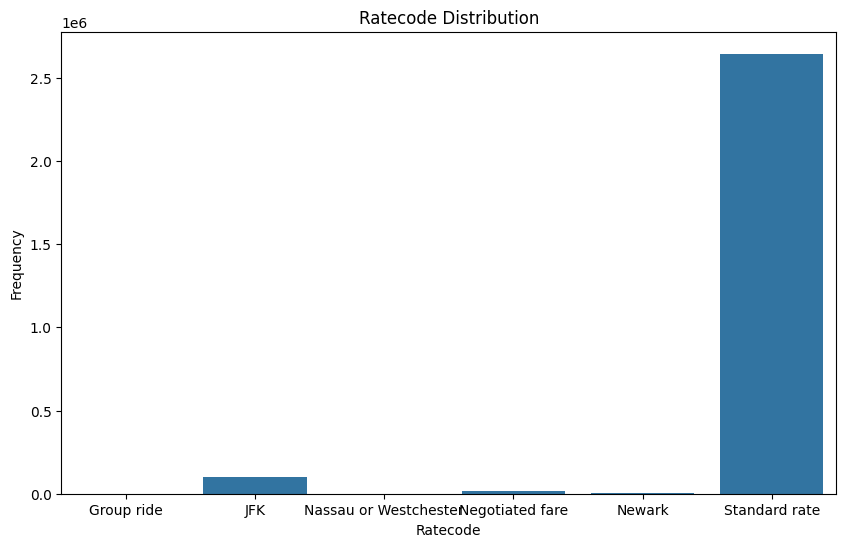

In [65]:
# analicemos distribucion de variable ratecode 
plt.figure(figsize=(10,6))
sns.countplot(data=df_nyc, x='ratecode')
plt.title('Ratecode Distribution')
plt.xlabel('Ratecode')
plt.ylabel('Frequency')
plt.show()

In [66]:
# analisis de variables para filas que sean ratecode negotiaded fare
# categoricas
df_nyc.nunique()

vendor                         2
tpep_pickup_datetime     1566696
tpep_dropoff_datetime    1565698
passenger_count               10
trip_distance               3510
ratecode                       6
payment_type                   5
fare_amount                 8309
extra                         46
mta_tax                        6
tip_amount                  3529
tolls_amount                 969
improvement_surcharge          5
total_amount               16392
congestion_surcharge           6
Airport_fee                    3
pickup_borough                 6
pickup_zone                  256
pickup_service_zone            4
dropoff_borough                6
dropoff_zone                 258
dropoff_service_zone           4
pickup_hour                   24
hour_bin                      12
dtype: int64

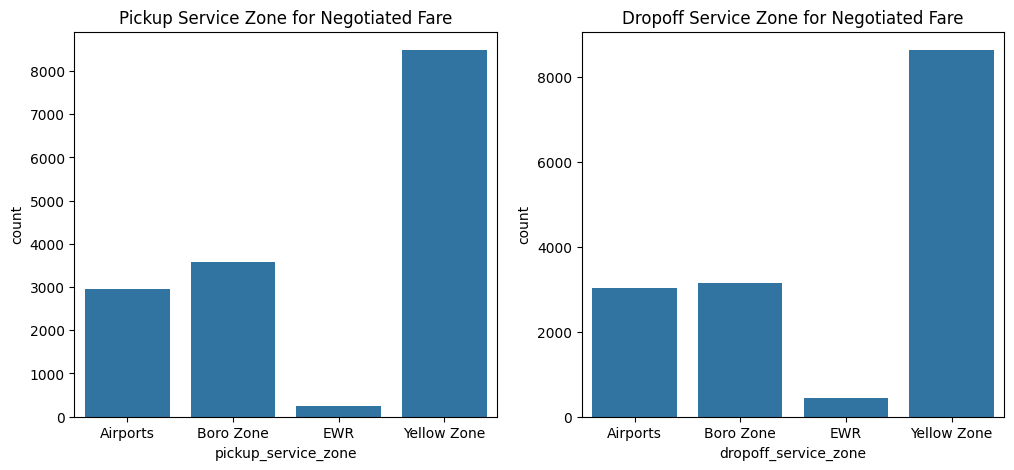

In [67]:
# filas que sean dropoff negotiaded fare head subplots de histograma de count de pickup_service_zone y dropoff_service_zone
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Negotiated fare'], x='pickup_service_zone')
plt.title('Pickup Service Zone for Negotiated Fare')
plt.subplot(1, 2, 2)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Negotiated fare'], x='dropoff_service_zone')
plt.title('Dropoff Service Zone for Negotiated Fare')
plt.show()

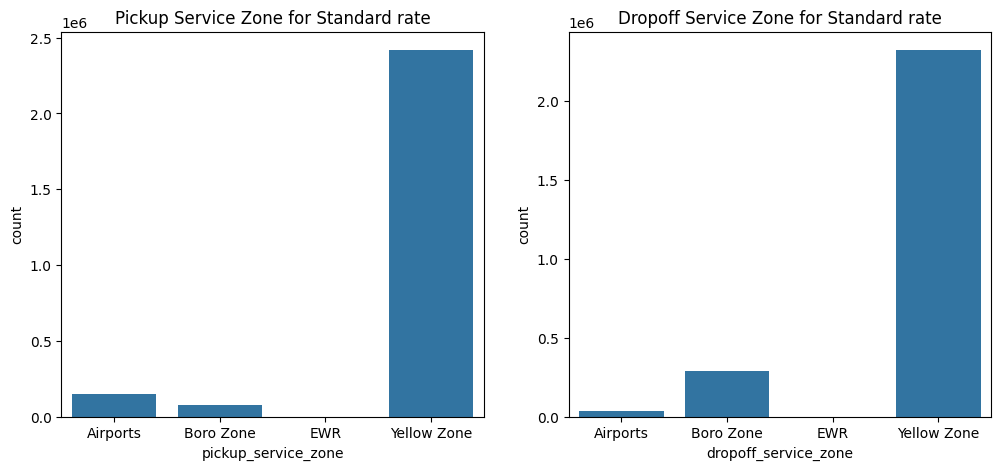

In [68]:
# para standard rate 
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Standard rate'], x='pickup_service_zone')
plt.title('Pickup Service Zone for Standard rate')
plt.subplot(1, 2, 2)
sns.countplot(data=df_nyc[df_nyc['ratecode'] == 'Standard rate'], x='dropoff_service_zone')
plt.title('Dropoff Service Zone for Standard rate')
plt.show()

In [69]:
# viendo esto podemos imputar estocasticamente ratecode en funcion de pickup_service_zone 
# creando tabla de probabilidades de ratecode por pickup_service_zone
ratecode_probs = df_nyc.groupby('pickup_service_zone')['ratecode'].value_counts(normalize=True).unstack().fillna(0)
# función para imputar ratecode basado en probabilidades
def imputar_ratecode(row):
    if pd.isnull(row['ratecode']):
        probs = ratecode_probs.loc[row['pickup_service_zone']]
        return np.random.choice(probs.index, p=probs.values)
    else:
        return row['ratecode']
df_nyc['ratecode'] = df_nyc.apply(imputar_ratecode, axis=1)

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\3100907202.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ratecode_probs = df_nyc.groupby('pickup_service_zone')['ratecode'].value_counts(normalize=True).unstack().fillna(0)


In [70]:
# passenger count lo imputamos por criterio de serie temporal. primero ffill luego bfill para asegurar completitud.
df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')
# nulos Expresado en porcentual y en absoluto
nulos_percent = df_nyc.isnull().mean() * 100
nulos_absolute = df_nyc.isnull().sum()
nulos_df = pd.DataFrame({'Nulos Absoluto': nulos_absolute, 'Nulos Porcentual': nulos_percent})
print(nulos_df)

C:\Users\60080956\AppData\Local\Temp\ipykernel_4192\620267316.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_nyc['passenger_count'] = df_nyc['passenger_count'].fillna(method='ffill').fillna(method='bfill')


                       Nulos Absoluto  Nulos Porcentual
vendor                              0              0.00
tpep_pickup_datetime                0              0.00
tpep_dropoff_datetime               0              0.00
passenger_count                     0              0.00
trip_distance                       0              0.00
ratecode                            0              0.00
payment_type                        0              0.00
fare_amount                         0              0.00
extra                               0              0.00
mta_tax                             0              0.00
tip_amount                          0              0.00
tolls_amount                        0              0.00
improvement_surcharge               0              0.00
total_amount                        0              0.00
congestion_surcharge                0              0.00
Airport_fee                         0              0.00
pickup_borough                      0           

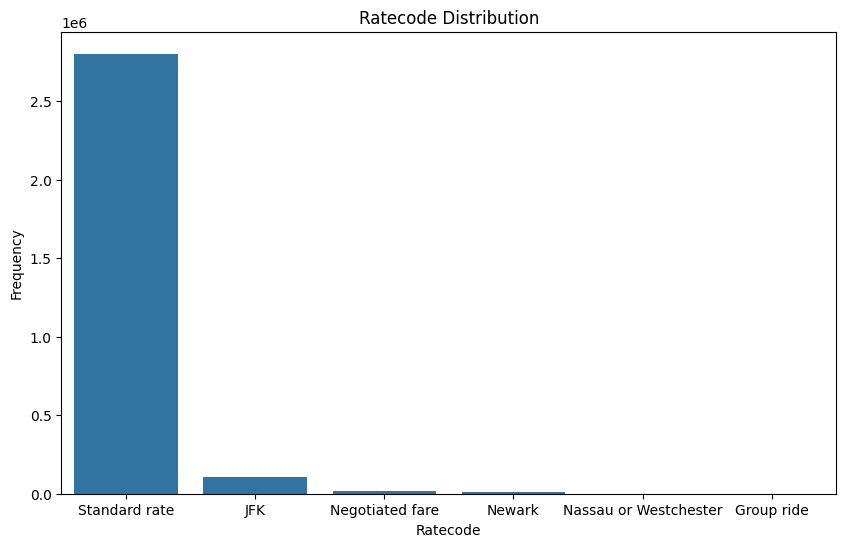

In [71]:
# analicemos distribucion de variable ratecode 
plt.figure(figsize=(10,6))
sns.countplot(data=df_nyc, x='ratecode')
plt.title('Ratecode Distribution')
plt.xlabel('Ratecode')
plt.ylabel('Frequency')
plt.show()

### Export 

In [ ]:
# exportamos df limpio en formato parquet. para esto separamos por mes para no tener archivos muy grandes
# agregamos columna mes y separamos
df_nyc['month'] = df_nyc['tpep_pickup_datetime'].dt.month
for month, group in df_nyc.groupby('month'):
    group.drop(columns=['month'], inplace=True)
    group.to_parquet(f"../dataset/04-null-processed/cleaned_yellow_tripdata_2024-{month:02d}.parquet", index=False)
